# Feature selection

# Setup Code
## Environment

In [1]:
### use brd4

import sys

print(sys.executable)

/home/oskar/anaconda3/envs/brd4/bin/python


## Imports

In [2]:
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn as sk
from rdkit import RDLogger
from tqdm import tqdm

## Jupyter Settings

In [3]:
### Random seed - using the same seed for robustness
SEED = 42
np.random.seed(SEED)

### NumPy arrays - floats
np.set_printoptions(
    precision=2,  # round values
    suppress=True,
)  # avoid scientific notation

### pandas DataFrames
pd.set_option("display.float_format", "{:.2f}".format)  # Round to 2 decimal places

### Initialize tqdm for pandas
tqdm.pandas()

### Suppress RDKit logs
RDLogger.DisableLog("rdApp.*")

### Re-enable logging if needed
# RDLogger.EnableLog('rdApp.*')

## Utils
- `utils/pd_mol.py` contains individual functions for processing rdkit mol objects in pandas DataFrames

In [4]:
### Add the utils directory to the path
sys.path.append(os.path.abspath("../utils"))

from pd_mol import render_mol
from similarity_sali import MorganSimilarity

# Data
To ensure reproducibility `01_brd4_inhibitors_2k.pkl` generated [here](../01_eda/01_pre_process.ipynb) is used for this analysis. They are described by (columns):
- `ID`: string - unique identifier from `ChEMBL`
- `Mol`: rdkit.Chem.rdchem.Mol - standardized inhibitor structure 
- `pIC50`: float - quantitative activity (negative logarithm of the half maximal inhibitory concentration in `mol / L`). 
- `active`: float - 1.00 (active), 0.00 (inactive)

2684


,ID,IC50_nM,active,Mol
0,CHEMBL5171062,0.33,1.00,
1,CHEMBL5171510,0.39,1.00,
2,CHEMBL5209870,0.40,1.00,

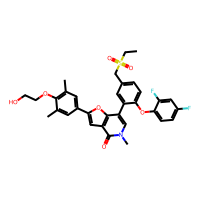
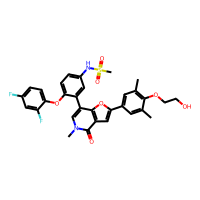
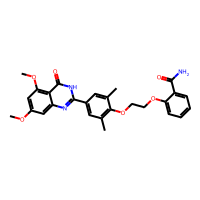

In [7]:
df = pd.read_pickle("../data/01_brd4_inhibitros_3k.pkl")
print(len(df))
render_mol(df.head(3))

# Dimension reduction with PCA

## Morgan fingerprints

From the [SALI analysis](../01_eda/02_activity_cliffs.ipynb) we know that `radius = 3` is important for this data set. Because we will reduce the complexity by PCA `nBits = 2048` is chosen. 

The method `utils.similarity_sali.MorganSimilarity.get_morgan_fingerprint()` is used to calculate the fingerprints. 

In [7]:
### Instantiate the class
morgan = MorganSimilarity(df, radius=3, nBits=2048, useChirality=True)

### Get the Morgan fingerprints
morgan.get_morgan_fingerprint()

### Format the fingerprints as NumPy array
morgan.format_fp("np_array")

morgan.fp

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(2397, 2048))

## Variance Analysis
Principal component analysis (PCA) ranks new features by the amount of variance each PC explains. If plotted in a cumulative fashion, the amount of variance explained for any number of chosen PCs.

In [8]:
### Instantiate the PCA class
pca = sk.decomposition.PCA(random_state=SEED)

### Fit the PCA model
all_PCs = pca.fit_transform(morgan.fp)

228 PCs explain 80.0% of the variance: 


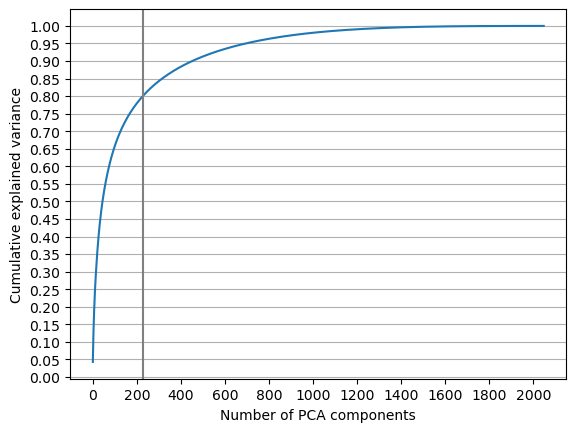

In [9]:
### Filter cumulative_variance for explaining 80% of the variance (choose between 80-95% based on elbow point)
explained_variance_threshold = 0.80

### Cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

### Find the index where cumulative variance exceeds threshold
num_components = np.argmax(cumulative_variance >= explained_variance_threshold) + 1

print(
    f"{num_components} PCs explain {explained_variance_threshold * 100}% of the variance: "
)

### Plot
features = range(pca.n_components_)

sns.lineplot(x=features, y=cumulative_variance)
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.xticks(np.arange(0, morgan.nBits, 200))
plt.yticks(np.arange(0, 1.05, 0.05))
plt.grid(True, which="both", axis="y")
plt.axvline(x=num_components, color="grey")
plt.show()

## Bias Analysis
### Accuracy Score
Because both classes are balanced, the choice of scoring metric is not crucial. **Accuracy** will be used as scoring metric. 

In [10]:
print(round(df["active"].mean(), 3), df["active"].value_counts())

0.496 active
0.00    1209
1.00    1188
Name: count, dtype: int64


For inbalanced data sets use multiple scoring metrics

- **Accuracy**:       Overall model correctness
- **Sensitivity**:    1 - false negative rate
- **Specificity**:    1 - false positive rate
- **MCC**:            Matthews Correlation Coefficient
- **ROC_AUC**:        includes prediction confidence

### Out-of-Bag Score
A random forest classifier with default hyperparameters is used for feature selection. This allows the use of out-of-bag (OOB) scoring and thus removes the need for splitting the data set in train and test data. 

The function `oob` is used to calculate the OOB scores for random forest classifier models trained on selected numbers of PCs. 

In [ ]:
def oob(n_components, X=all_PCs, y=df["active"].values):
    ### Instantiate Random Forest Classifier
    rf_clf = sk.ensemble.RandomForestClassifier(
        oob_score=True,  # quasi test score
        random_state=SEED,  # reproducability
    )

    ### Fit the model with n PCs
    rf_clf.fit(X[:, : int(n_components)], y)

    ### Calculate the OOB score (uses accuracy as default)
    oob_score = rf_clf.oob_score_

    return oob_score

In [ ]:
### Create a DataFrame to store the results
results_df = pd.DataFrame(
    np.logspace(0, 11, num=12, base=2).astype(int), columns=["n_PCs"]
)

### Add the cumulative variance for each n_PC
results_df["cum_var"] = cumulative_variance[results_df["n_PCs"] - 1]

### Calculate the OOB score for each n_PC
results_df["oob_score"] = results_df["n_PCs"].progress_apply(oob)
results_df

100%|██████████| 12/12 [00:57<00:00,  4.75s/it]


,n_PCs,cum_var,oob_score
0,1,0.04,0.59
1,2,0.08,0.74
2,4,0.13,0.83
3,8,0.21,0.87
4,16,0.31,0.88
5,32,0.43,0.89
6,64,0.57,0.90
7,128,0.70,0.91
8,256,0.82,0.91
9,512,0.92,0.90


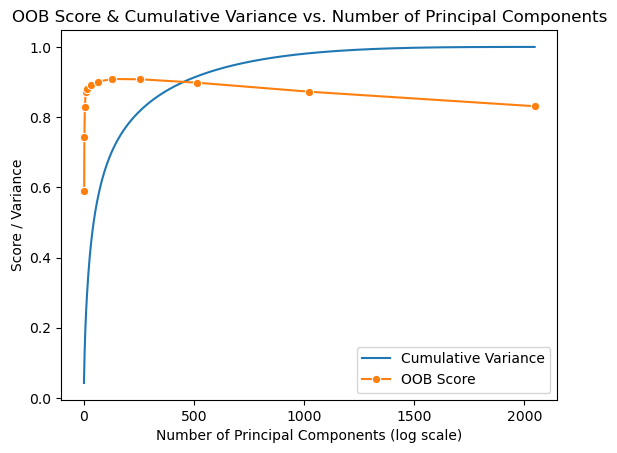

In [ ]:
### Plot both OOB score and cumulative variance
sns.lineplot(x=features, y=cumulative_variance, label="Cumulative Variance")
sns.lineplot(data=results_df, x="n_PCs", y="oob_score", marker="o", label="OOB Score")

### Log scale for x-axis
plt.xlabel("Number of Principal Components (log scale)")
plt.ylabel("Score / Variance")
plt.title("OOB Score & Cumulative Variance vs. Number of Principal Components")
plt.legend()
plt.show()


In [ ]:
### Highest OOB score
results_df.loc[results_df["oob_score"] == results_df["oob_score"].max()]

,n_PCs,cum_var,oob_score
7,128,0.70,0.91


In [ ]:
### 95% of highest OOB score
results_df.loc[results_df["oob_score"] >= results_df["oob_score"].max() * 0.95].head(1)

,n_PCs,cum_var,oob_score
3,8,0.21,0.87


# Conclusion
The DataFrame `results_df` and the plot above show:
- The highest OOB score was achieved using `128 PCs`
- Clear overfitting is observed when more than 128 features are used
- As few as `8 PCs` achieve an OOB score within 5% of the maximum score
- Clear underfitting is observed when less than 8 features are used
- `32 PCs` will be used for classification models. 

To avoid data leakage PCA will be performed after data splitting.  

# Export Morgan Fingerprints

In [ ]:
with open("../data/03_morgan.pkl", "wb") as file:
    pickle.dump(morgan, file)